# Section 6: Model Selection


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

In [3]:
# 1. Load Titanic Dataset from OpenML

print('Fetching Titanic dataset from OpenML...')
titanic = fetch_openml(name='titanic', version=1, as_frame=True, parser='auto')
titanic_df = titanic.frame

# 2. Load LendingClub Dataset via OpenML

print('Fetching LendingClub dataset from OpenML...')
lending = fetch_openml(name='lending-club-loan-data', version=1, as_frame=True, parser='auto')
lending_df = lending.frame

print('Datasets loaded successfully!')

Fetching Titanic dataset from OpenML...
Fetching LendingClub dataset from OpenML...
Datasets loaded successfully!


## Titanic dataset

Titanic is a binary classification problem.

Target:

- `survived = 0`: did not survive
- `survived = 1`: survived

We will compare several model families:

1. Logistic Regression  
2. Decision Tree  
3. Random Forest  
4. Gradient Boosting  
5. KNN  
6. Linear SVM  

This turns model selection into an empirical comparison.

In [ ]:
titanic_model = titanic_df.copy()

target_col = "survived"

# Convert target to integer
titanic_model[target_col] = titanic_model[target_col].astype(int)

# Treat pclass as categorical
if "pclass" in titanic_model.columns:
    titanic_model["pclass"] = titanic_model["pclass"].astype("category")

# Separate X and y first
X_titanic = titanic_model.drop(columns=[target_col]).copy()
y_titanic = titanic_model[target_col].copy()

# Drop columns that are not useful or may create leakage
cols_to_drop = ["name", "ticket", "cabin", "boat", "body", "home.dest"]
X_titanic = X_titanic.drop(columns=cols_to_drop, errors="ignore")

# Identify categorical and numeric columns
cat_cols = X_titanic.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()
num_cols = X_titanic.select_dtypes(include=[np.number]).columns.tolist()

# Clean categorical columns
for col in cat_cols:
    X_titanic[col] = X_titanic[col].astype("object")
    X_titanic[col] = X_titanic[col].fillna("missing")
    X_titanic[col] = X_titanic[col].astype(str).str.strip().str.lower()

# One-hot encode categorical columns
X_titanic = pd.get_dummies(
    X_titanic,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

print("Titanic X shape:", X_titanic.shape)
print("Titanic y shape:", y_titanic.shape)

display(X_titanic.head())
display(y_titanic.value_counts(normalize=True))

In [ ]:
# Train-test split

X_train_titanic, X_test_titanic, y_train_titanic, y_test_titanic = train_test_split(
    X_titanic,
    y_titanic,
    test_size=0.2,
    random_state=42,
    stratify=y_titanic
)

# Impute numeric columns — fit on train only to prevent data leakage
num_imputer = SimpleImputer(strategy="median")
X_train_titanic[num_cols] = num_imputer.fit_transform(X_train_titanic[num_cols])
X_test_titanic[num_cols] = num_imputer.transform(X_test_titanic[num_cols])

print("Train shape:", X_train_titanic.shape)
print("Test shape:", X_test_titanic.shape)

### Define Candidate Models

Some models need scaling, such as Logistic Regression, KNN, and SVM.

Tree-based models usually do not require scaling.

In [6]:
# Candidate models for Titanic

titanic_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=4
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
    
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    
    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(random_state=42, max_iter=5000))
    ])
}

### Evaluation Function

We evaluate models using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Training time

In [7]:
def evaluate_classification_models(models, X_train, X_test, y_train, y_test):
    results = []
    
    for model_name, model in models.items():
        start_time = time.time()
        
        model.fit(X_train, y_train)
        train_time = time.time() - start_time
        
        y_pred = model.predict(X_test)
        
        # Some models support predict_proba, others support decision_function
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, y_score)
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_test)
            roc_auc = roc_auc_score(y_test, y_score)
        else:
            roc_auc = np.nan
        
        results.append({
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc,
            "train_time_seconds": train_time
        })
    
    return pd.DataFrame(results).sort_values("f1", ascending=False)

In [8]:
# Evaluate Titanic models

titanic_results = evaluate_classification_models(
    titanic_models,
    X_train_titanic,
    X_test_titanic,
    y_train_titanic,
    y_test_titanic
)

display(titanic_results)

,model,accuracy,precision,recall,f1,roc_auc,train_time_seconds
1,Decision Tree,0.835878,0.813187,0.74,0.774869,0.875802,0.012345
3,Gradient Boosting,0.839695,0.845238,0.71,0.771739,0.888735,0.205755
5,Linear SVM,0.816794,0.776596,0.73,0.752577,0.867438,0.014861
2,Random Forest,0.801527,0.740000,0.74,0.740000,0.859537,0.442670
0,Logistic Regression,0.805344,0.763441,0.71,0.735751,0.867253,0.029870
4,KNN,0.793893,0.725490,0.74,0.732673,0.824753,0.011695


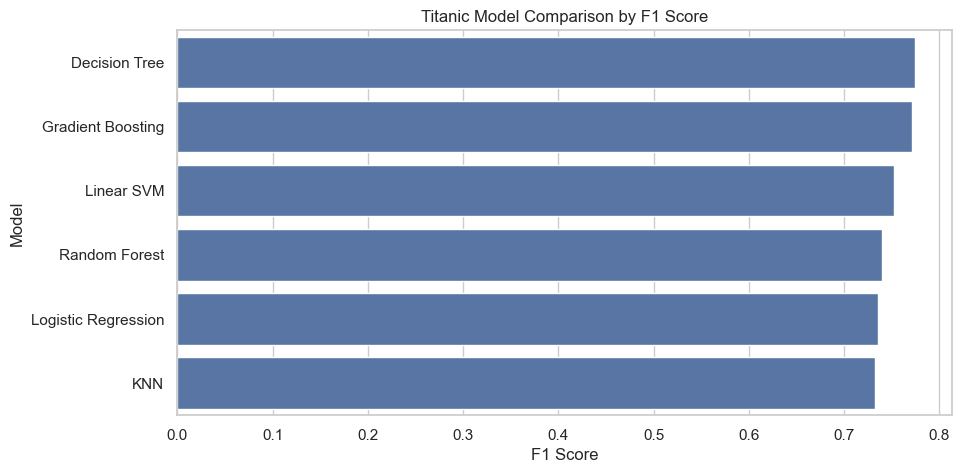

In [9]:
# Visualize Titanic model comparison

plt.figure(figsize=(10, 5))
sns.barplot(data=titanic_results, x="f1", y="model")
plt.title("Titanic Model Comparison by F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.show()

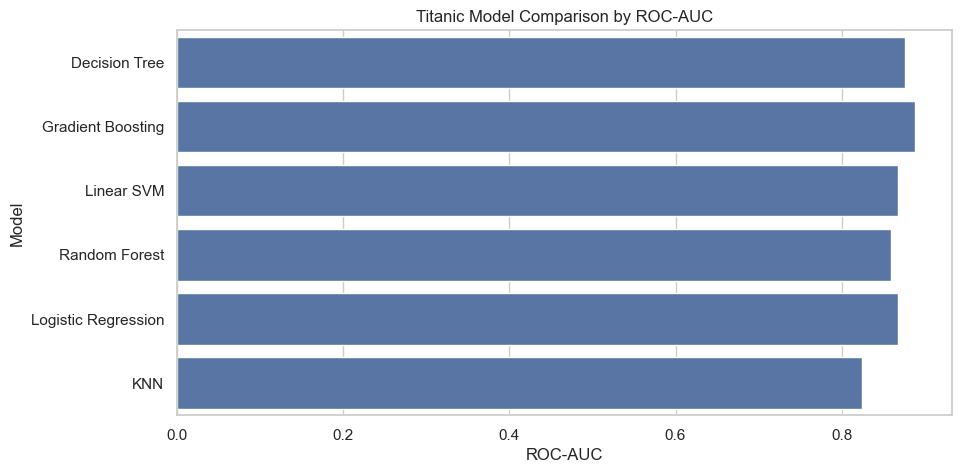

In [10]:
plt.figure(figsize=(10, 5))
sns.barplot(data=titanic_results, x="roc_auc", y="model")
plt.title("Titanic Model Comparison by ROC-AUC")
plt.xlabel("ROC-AUC")
plt.ylabel("Model")
plt.show()

### Model Selection Interpretation

For Titanic:

- Logistic Regression is interpretable and usually a strong baseline.
- Decision Tree is easy to explain but can overfit.
- Random Forest and Gradient Boosting usually capture non-linear patterns better.
- KNN depends heavily on scaling and distance.
- SVM can work well but is less interpretable.

In [11]:
# Add qualitative model selection criteria

titanic_model_notes = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "KNN",
        "Linear SVM"
    ],
    "interpretability": [
        "High",
        "High",
        "Medium",
        "Medium",
        "Low",
        "Medium"
    ],
    "handles_nonlinearity": [
        "Low",
        "Medium",
        "High",
        "High",
        "Medium",
        "Low to Medium"
    ],
    "scaling_needed": [
        "Yes",
        "No",
        "No",
        "No",
        "Yes",
        "Yes"
    ],
    "good_baseline_use_case": [
        "Interpretable baseline",
        "Explainable rules",
        "Strong non-linear baseline",
        "High predictive performance",
        "Distance-based comparison",
        "Margin-based classifier"
    ]
})

display(titanic_model_notes)

,model,interpretability,handles_nonlinearity,scaling_needed,good_baseline_use_case
0,Logistic Regression,High,Low,Yes,Interpretable baseline
1,Decision Tree,High,Medium,No,Explainable rules
2,Random Forest,Medium,High,No,Strong non-linear baseline
3,Gradient Boosting,Medium,High,No,High predictive performance
4,KNN,Low,Medium,Yes,Distance-based comparison
5,Linear SVM,Medium,Low to Medium,Yes,Margin-based classifier


## LendingClub dataset

LendingClub is also a binary classification problem.

Target:

- `not.fully.paid = 0`: fully paid
- `not.fully.paid = 1`: not fully paid

This dataset is usually imbalanced, so recall, precision, F1-score, and ROC-AUC are more useful than accuracy alone.

In [ ]:
# ============================================================
# 6B. Prepare LendingClub Data
# ============================================================

lc_model = lending_df.copy()

target_col = "not.fully.paid"

# Convert target to integer
lc_model[target_col] = lc_model[target_col].astype(int)

# Separate X and y first
X_lc = lc_model.drop(columns=[target_col]).copy()
y_lc = lc_model[target_col].copy()

# Identify categorical and numeric columns
cat_cols = X_lc.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()
num_cols = X_lc.select_dtypes(include=[np.number]).columns.tolist()

# Clean categorical columns
for col in cat_cols:
    X_lc[col] = X_lc[col].astype("object")
    X_lc[col] = X_lc[col].fillna("missing")
    X_lc[col] = X_lc[col].astype(str).str.strip().str.lower()

# One-hot encode categorical columns
X_lc = pd.get_dummies(
    X_lc,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

# Replace infinite values with NaN — imputation handled after split
X_lc = X_lc.replace([np.inf, -np.inf], np.nan)

print("LendingClub X shape:", X_lc.shape)
print("LendingClub y shape:", y_lc.shape)

display(X_lc.head())
display(y_lc.value_counts(normalize=True))

In [ ]:
# Train-test split

X_train_lc, X_test_lc, y_train_lc, y_test_lc = train_test_split(
    X_lc,
    y_lc,
    test_size=0.2,
    random_state=42,
    stratify=y_lc
)

# Impute numeric columns — fit on train only to prevent data leakage
num_imputer = SimpleImputer(strategy="median")
X_train_lc[num_cols] = num_imputer.fit_transform(X_train_lc[num_cols])
X_test_lc[num_cols] = num_imputer.transform(X_test_lc[num_cols])

print("Train shape:", X_train_lc.shape)
print("Test shape:", X_test_lc.shape)

### Define Candidate Models

For LendingClub, we include class weights because the positive class is usually smaller.

In [ ]:
# Candidate models for LendingClub

lc_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=5,
        class_weight="balanced"
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    
    "Gradient Boosting": HistGradientBoostingClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),
    
    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(
            random_state=42,
            max_iter=5000,
            class_weight="balanced"
        ))
    ])
}

In [16]:
# Evaluate LendingClub models

lc_results = evaluate_classification_models(
    lc_models,
    X_train_lc,
    X_test_lc,
    y_train_lc,
    y_test_lc
)

display(lc_results)

,model,accuracy,precision,recall,f1,roc_auc,train_time_seconds
5,Linear SVM,0.643006,0.242134,0.576547,0.341040,0.683798,0.059846
0,Logistic Regression,0.640397,0.239071,0.570033,0.336862,0.684468,0.030814
1,Decision Tree,0.615866,0.226054,0.576547,0.324771,0.633554,0.049330
4,KNN,0.823069,0.283784,0.068404,0.110236,0.586506,0.008830
3,Gradient Boosting,0.836639,0.375000,0.029316,0.054381,0.663890,1.409472
2,Random Forest,0.839770,0.500000,0.009772,0.019169,0.668640,1.060546


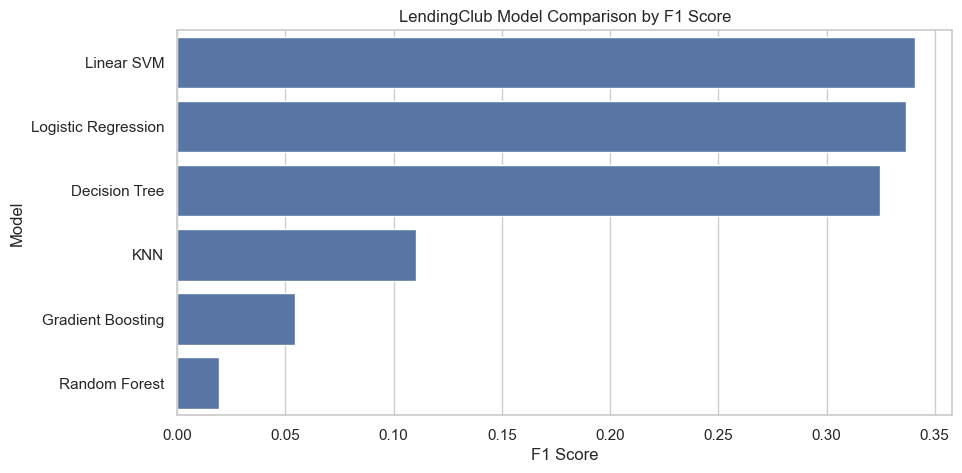

In [17]:
# Visualize LendingClub model comparison by F1

plt.figure(figsize=(10, 5))
sns.barplot(data=lc_results, x="f1", y="model")
plt.title("LendingClub Model Comparison by F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.show()

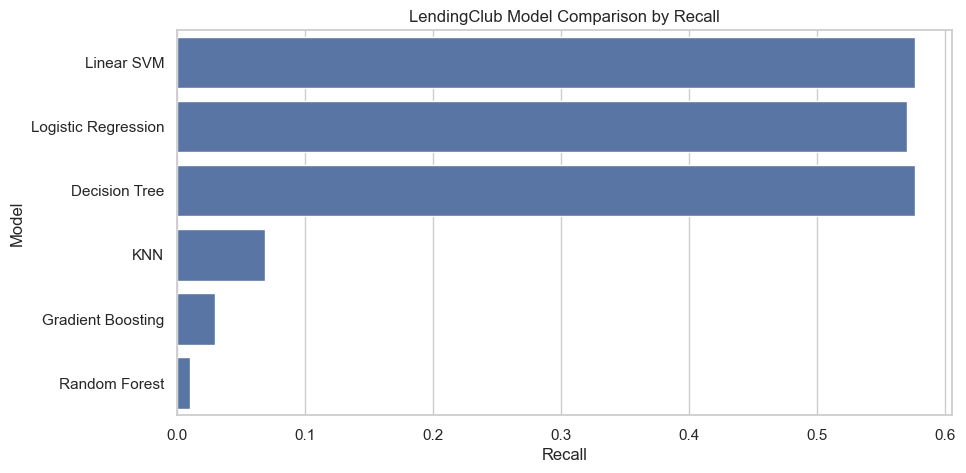

In [18]:
# Visualize LendingClub model comparison by Recall

plt.figure(figsize=(10, 5))
sns.barplot(data=lc_results, x="recall", y="model")
plt.title("LendingClub Model Comparison by Recall")
plt.xlabel("Recall")
plt.ylabel("Model")
plt.show()

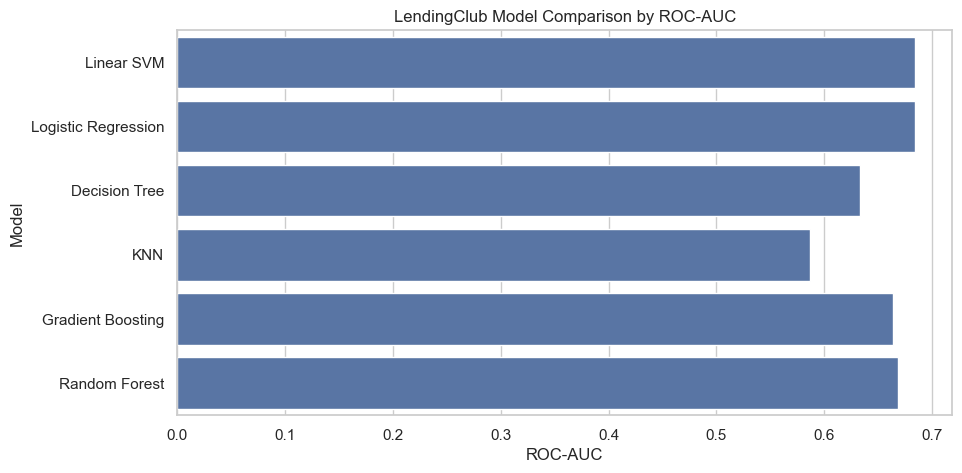

In [19]:
# Visualize LendingClub model comparison by ROC-AUC

plt.figure(figsize=(10, 5))
sns.barplot(data=lc_results, x="roc_auc", y="model")
plt.title("LendingClub Model Comparison by ROC-AUC")
plt.xlabel("ROC-AUC")
plt.ylabel("Model")
plt.show()

### Model Selection Interpretation

For LendingClub:

- Accuracy can be misleading because the dataset is imbalanced.
- Recall is important if missing risky loans is costly.
- Precision is important if falsely rejecting good borrowers is costly.
- Logistic Regression is a strong interpretable baseline.
- Tree-based models can capture non-linear risk patterns.
- Random Forest and Gradient Boosting are strong candidates for performance.

In [20]:
# Add qualitative model selection criteria

lc_model_notes = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "KNN",
        "Linear SVM"
    ],
    "interpretability": [
        "High",
        "High",
        "Medium",
        "Medium",
        "Low",
        "Medium"
    ],
    "handles_nonlinearity": [
        "Low",
        "Medium",
        "High",
        "High",
        "Medium",
        "Low to Medium"
    ],
    "scaling_needed": [
        "Yes",
        "No",
        "No",
        "No",
        "Yes",
        "Yes"
    ],
    "suitable_for_lendingclub": [
        "Strong baseline; explainable risk factors",
        "Explainable but may overfit",
        "Good non-linear model",
        "Strong predictive model",
        "Usually not ideal for high-dimensional one-hot data",
        "Useful linear margin model"
    ]
})

display(lc_model_notes)

,model,interpretability,handles_nonlinearity,scaling_needed,suitable_for_lendingclub
0,Logistic Regression,High,Low,Yes,Strong baseline; explainable risk factors
1,Decision Tree,High,Medium,No,Explainable but may overfit
2,Random Forest,Medium,High,No,Good non-linear model
3,Gradient Boosting,Medium,High,No,Strong predictive model
4,KNN,Low,Medium,Yes,Usually not ideal for high-dimensional one-hot...
5,Linear SVM,Medium,Low to Medium,Yes,Useful linear margin model


## Section 6 Summary

Model selection can be made practical by comparing candidate models on:

1. Predictive performance  
2. Interpretability  
3. Training speed  
4. Scaling requirement  
5. Ability to capture non-linear patterns  
6. Suitability for imbalanced classification  

For Titanic, interpretability and predictive performance are both useful.

For LendingClub, recall, precision, F1-score, and ROC-AUC matter more than accuracy because the target class is imbalanced.